In [6]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import warnings
import pandas as pd
import gc
import glob
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams['font.size'] = 16         
plt.rcParams['axes.titlesize'] = 16   
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = "lower"
plt.rcParams['image.cmap'] = 'magma'

In [9]:
storage_folder = '/net/vdesk/data2/deklerk/GAAP_data/flux_files'
processed_file = "/net/vdesk/data2/deklerk/GAAP_data/processed.txt"
catalog_folder = '/net/vdesk/data2/deklerk/GAAP_data/catalog_files'

In [4]:
with open(processed_file, "r") as f:
    processed = set(line.strip() for line in f)
print(processed)

{'102044823', '102160610', '102070859', '102022977', '102021990', '102022475', '102157957', '102021504', '102022477', '102019128', '102157954', '102160877', '102160333', '102159191', '102157629', '102158581', '102021505', '102160335', '102046762', '102020063', '102158888', '102041032', '102021496', '102042912', '102021978', '102022978', '102022476', '102020532', '102019589', '102023987', '102022975', '102021503', '102021986', '102021989', '102158278', '102020060', '102159490', '102018664', '102021013', '102018668', '102022481', '102021500', '102043551', '102158590', '102019129', '102046109', '102021018', '102019592', '102042917', '102160612', '102020061', '102158892', '102019126', '102044824', '102043548', '102158887', '102158270', '102157951', '102042919', '102019130', '102021006', '102018211', '102159188', '102021979', '102157631', '102021987', '102160608', '102159195', '102019131', '102021011', '102020066', '102018212', '102021982', '102021991', '102160875', '102070144', '102159488'

In [5]:
gc.collect()

0

In [10]:
all_fluxes = None
stop_index = 5
total = 0
for i, tile_index in enumerate(processed):
    print(i)
    catalog_file = glob.glob(f'{catalog_folder}/EUC_MER_FINAL-CAT_TILE{tile_index}*.fits')[0]
    with fits.open(catalog_file, memmap=True) as hdul:
        cat = Table(hdul[1].data)['POINT_LIKE_PROB']
    if i > stop_index:
        break
    if all_fluxes is None:
        all_fluxes = pd.read_csv(f'{storage_folder}/{tile_index}_fluxes.csv')
        all_fluxes['point_like_prob_mer'] = np.array(cat.data, dtype='<f8')
    else:
        fluxes = pd.read_csv(f'{storage_folder}/{tile_index}_fluxes.csv')
        fluxes['point_like_prob_mer'] = np.array(cat.data, dtype='<f8')
        all_fluxes = pd.concat([all_fluxes, fluxes], ignore_index=True)

0
1
2
3
4
5
6


In [11]:
# all_fluxes = pd.read_pickle(f'{storage_folder}/all_fluxes.pkl')
print(len(all_fluxes))
all_fluxes

527173


,id,ra,dec,weight_size,DES-Z,DES-Z_sigma,DES-I,DES-I_sigma,DES-R,DES-R_sigma,...,CFIS-U,CFIS-U_sigma,CFIS-R,CFIS-R_sigma,PANSTARRS-I,PANSTARRS-I_sigma,WISHES-G,WISHES-G_sigma,WISHES-Z,WISHES-Z_sigma
0,-523938110277525163,52.393811,-27.752516,0.702283,-72.673541,699.268594,48.683020,406.962174,148.089087,2.458986e+02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-519653501277524734,51.965350,-27.752473,0.702283,444.395980,729.909799,563.414261,417.529894,422.385425,2.775574e+02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-523387830277529050,52.338783,-27.752905,0.702283,1561.034773,699.143112,1165.238308,406.254201,1053.874539,2.449429e+02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-523387852277525402,52.338785,-27.752540,0.702283,6239.723876,699.532999,5780.654580,406.221469,5480.320614,2.452744e+02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-524597488277523093,52.459749,-27.752309,0.702283,156.430440,699.278853,319.507666,407.773993,120.393996,2.461277e+02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527168,-598572184467456747,59.857218,-46.745675,0.702283,848.201764,711.388840,297.579947,423.274012,252.348244,2.229071e+02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
527169,-597129674467456467,59.712967,-46.745647,0.702283,152.523316,713.116997,0.580471,436.319531,37.137547,2.292618e+02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
527170,-596747470467450402,59.674747,-46.745040,0.702283,104.949281,819.532237,141.135582,440.552719,14.765812,6.232414e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
527171,-597726714467443090,59.772671,-46.744309,0.702283,158.315853,710.868528,3.719880,419.467269,55.431197,2.215326e+02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
all_fluxes.columns

Index(['id', 'ra', 'dec', 'weight_size', 'DES-Z', 'DES-Z_sigma', 'DES-I',
       'DES-I_sigma', 'DES-R', 'DES-R_sigma', 'DES-G', 'DES-G_sigma', 'NIR-H',
       'NIR-H_sigma', 'NIR-Y', 'NIR-Y_sigma', 'NIR-J', 'NIR-J_sigma', 'VIS',
       'VIS_sigma', 'point_like_prob_mer', 'CFIS-U', 'CFIS-U_sigma', 'CFIS-R',
       'CFIS-R_sigma', 'PANSTARRS-I', 'PANSTARRS-I_sigma', 'WISHES-G',
       'WISHES-G_sigma', 'WISHES-Z', 'WISHES-Z_sigma'],
      dtype='str')

In [8]:
from scipy.ndimage import gaussian_filter

1651152


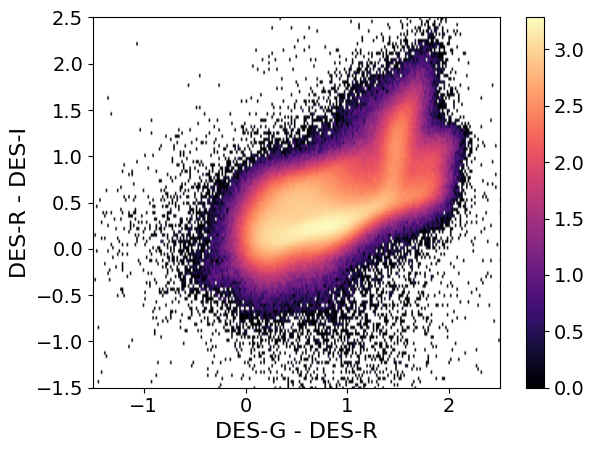

In [ ]:
filter_1 = 'DES-G'   # e.g., master_table column name
filter_2 = 'DES-R'
filter_3 = filter_2
filter_4 = 'DES-I'

plot_error = True

# Compute colors from master_table fluxes
x_color = -2.5 * np.log10(all_fluxes[filter_1] / all_fluxes[filter_2])
y_color = -2.5 * np.log10(all_fluxes[filter_3] / all_fluxes[filter_4])

# Compute SNR
snr_x = all_fluxes[filter_1] / all_fluxes[f'{filter_1}_sigma']
snr_y = all_fluxes[filter_2] / all_fluxes[f'{filter_2}_sigma']

# Compute errors from sigma dictionary
xerr = 2.5 / np.log(10) * np.sqrt(
    (all_fluxes[f'{filter_1}_sigma'] / all_fluxes[filter_1])**2 +
    (all_fluxes[f'{filter_2}_sigma'] / all_fluxes[filter_2])**2
)
yerr = 2.5 / np.log(10) * np.sqrt(
    (all_fluxes[f'{filter_3}_sigma'] / all_fluxes[filter_3])**2 +
    (all_fluxes[f'{filter_4}_sigma'] / all_fluxes[filter_4])**2
)

SNR_CUTOFF = 10
mask = (snr_x > SNR_CUTOFF) & (snr_y > 3) & (np.isfinite(x_color)) & (np.isfinite(y_color))
# plt.errorbar(
#     x_color[mask], y_color[mask],
#     xerr=xerr[mask] * plot_error, yerr=yerr[mask] * plot_error,
#     fmt='o', c='b', ms=1, elinewidth=0.5, alpha=0.8, label='GAAP', rasterized=True
# )
H, xedges, yedges = np.histogram2d(x_color[mask], y_color[mask], bins=1000)
# H[H>0] = np.log(H)[H>0]
# apply Gaussian smoothing
H_smooth = gaussian_filter(np.log(H), sigma=.1)
plt.imshow(
    np.log10(H).T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto'
)
# plt.hexbin(x_color[mask], y_color[mask], gridsize=500)
print(np.sum(mask))
left, right, up, down = -1.5, 2.5, -1.5, 2.5
plt.xlabel(f'{filter_1} - {filter_2}')
plt.ylabel(f'{filter_3} - {filter_4}')
plt.xlim(left, right)
plt.ylim(up, down)
# plt.grid(True)
plt.colorbar()
plt.tight_layout()
plt.show()

In [13]:
%load_ext autoreload
%autoreload 2

import sys, os
import glob
project_root = os.path.abspath("../..")  # one level up from /notebooks
if project_root not in sys.path:
    sys.path.append(project_root)
from src.utils import create_psf_from_psf_grid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
data_folder = '/net/vdesk/data2/deklerk/GAAP_data/temp'

CFIS-R


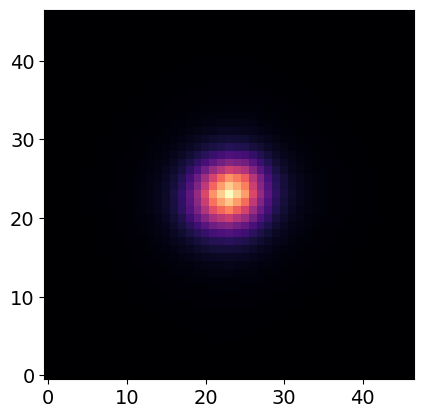

CFIS-U


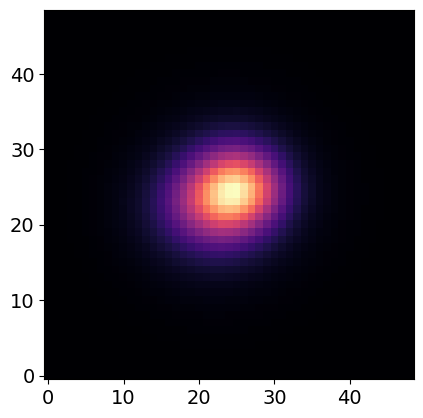

PANSTARRS-I


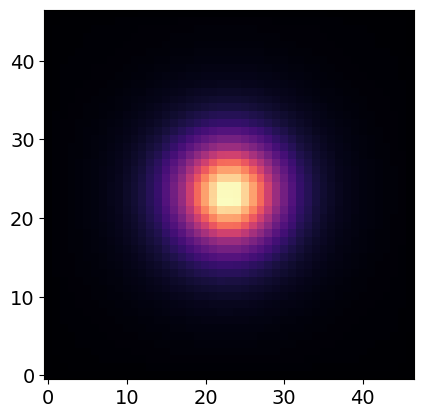

WISHES-G


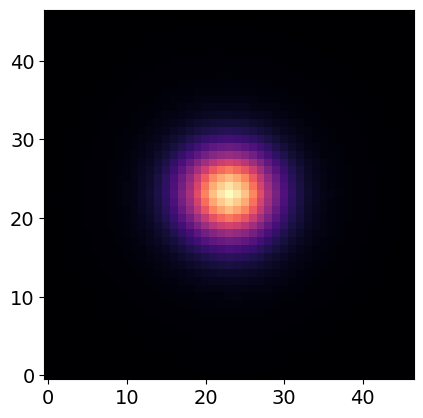

WISHES-Z


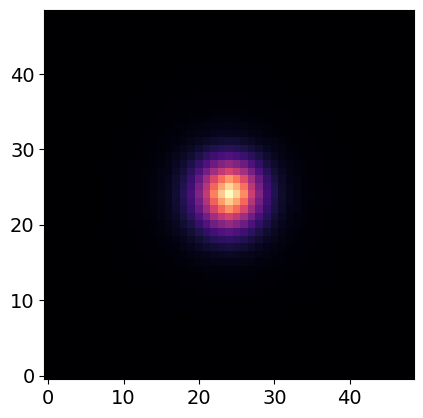

NIR-Y


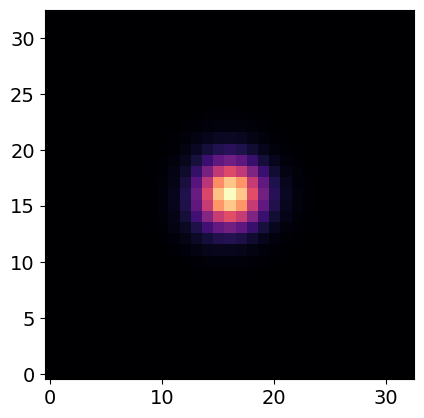

NIR-J


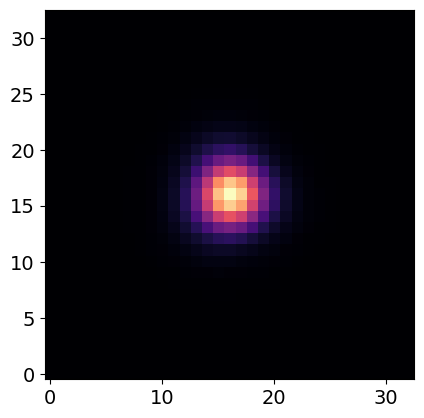

NIR-H


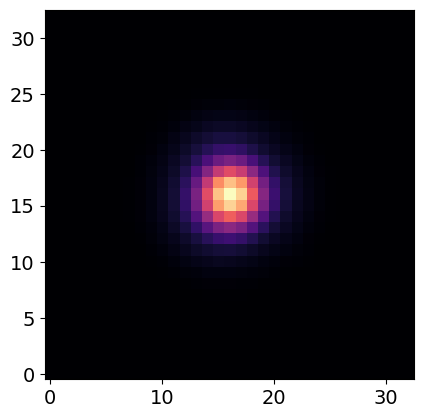

DES-G
DES-R
DES-I
DES-Z
VIS


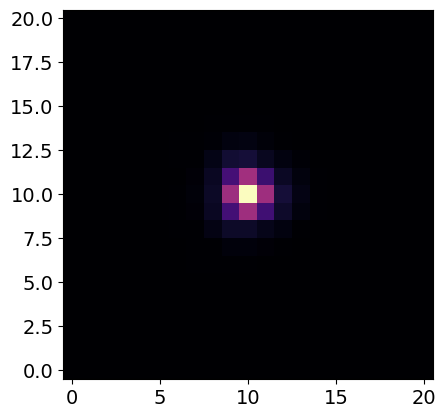

In [22]:
psf_size_dictionary = {'CFIS-R': 47, 'CFIS-U': 49, 'PANSTARRS-I': 47, 'WISHES-G': 47, 'WISHES-Z': 49,
                       'NIR-Y': 33, 'NIR-J': 33, 'NIR-H': 33, 'DES-G': 49, 'DES-R': 49, 'DES-I': 49, 'DES-Z': 49, 'VIS': 21}
for filter_ in psf_size_dictionary.keys():
    print(filter_)
    try:
        file = glob.glob(f'{data_folder}/EUC_MER_CATALOG-PSF-{filter_}_*.fits')[0]
        with fits.open(file, memmap=True) as hdul:
            psf_grid = hdul[1].data
        plt.imshow(create_psf_from_psf_grid(psf_grid, psf_size_dictionary[filter_], 40))
        plt.show()
    except Exception:
        continue